In [1]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy import optimize

# Methods for Solving Nonlinear Equations.

## Fixed-Point or Relaxation Method.

- This method is applied to equations of the form:
 
    $$x = f(x),$$
 
    and consists of finding a solution iteratively. That is, starting from an initial estimate of the solution $x_0$, the next iterate is:

    $$x_1 = f(x_0),$$

    so that after $k$ iterations, the exact solution has been found if:

    $$x_{k+1} - x_k = f(x_k) - x_k = 0.$$

- The key point is therefore to study under which conditions this iterative process converges to the exact solution.

- To do so, suppose we have an estimate of the solution $x_i$ and define the exact solution as $\bar x$.

- Expanding in a Taylor series around the exact solution, we obtain:

    $$x_{i+1} = f(x_i) = f(\bar x) + (x_i - \bar x)\, f'(\bar x) + \cdots
    = \bar x + (x_i - \bar x)\, f'(\bar x) + \cdots,$$

    therefore, the difference between our next estimate and the exact solution is:

    $$x_{i+1} - \bar x = (x_i - \bar x)\, f'(\bar x) + \cdots.$$

- The distance of the successive estimates to the exact solution will decrease if and only if:

$$\lvert f'(\bar x) \rvert < 1.$$

---

In [2]:
import numpy as np

def fixedpoint(f, eps):
    it = 0
    err = 1.0
    x0 = 1.0
    while err > eps:
        x1 = f(x0)
        err = abs(x1 - x0)
        it += 1
        x0 = x1
    print("Fixed-Point method's iterations:", it)
    return x1


def f(x):
    return 2 - np.exp(-x)


x = fixedpoint(f, 1e-6)

print(x)
print()
print(f(x))


Fixed-Point method's iterations: 9
1.8414055651879888

1.8414056453310121


### Non-convergence of the fixed-point method.

* If the derivative of the function at the solution satisfies

    $$\vert f'(\bar x)\vert>1,$$

    the fixed-point method will not converge towards the solution.
---

In [3]:
def fixedpoint2(g, eps):
    x = 0
    for k in range(10):
        x = g(x)
        err = abs(x - g(x))
        if err < eps:
            break
    return x


def g(x):
    return np.sqrt(1 - np.log(x))


x = fixedpoint2(g, 1e-3)
print(x)
print()
print(g(x))

nan

nan


- There may be more than one solution:
<br/>

    - In that case, the value of the solution found by the relaxation method will depend on the initial value.
    - Thus, if we have an approximate idea of the solution we are looking for, we should use it as the initial value.


- There are functions whose inverse does not exist or cannot be determined analytically.
<br/>

    - In that case, if $|f'(\bar x)|>1$ it will not be possible to find a solution.
    
    
    
- However, there are occasions in which, even in that case, it is still possible to find a solution by partially reordering the function.

---


In [4]:
def f(x):
    return x**2 + np.sin(2*x)


a = fixedpoint(f, 1e-3)
print(a)

Fixed-Point method's iterations: 13
nan


### Convergence and error estimation of the fixed-point method.

- Once we have seen the conditions under which the fixed-point method converges, the next step is to know how fast it does so.


- Given an iteration $i$ the difference with the exact solution is

    \begin{align}
       |x_{i+1}-\bar x| =|x_i-\bar x\,|\,|f'\left(\bar x\right)|+\cdots=&\;|x_{i-1}-\bar x\,|\,|f'\left(\bar x\right)|^2+\cdots=\cdots=|x_{0}-\bar x\,|\,|f'\left(\bar x\right)\,|^{i+1}+\cdots,\nonumber\\
    =\;&|x_0-\bar x\,|\;\text{e}^{(i+1)\log |f'(\bar x)|}+\cdots=|x_0-\bar x\,|\;\text{e}^{-(i+1)\log\left(1/|f'(\bar  x)|\right)}+\cdots
    \end{align}

    which implies that the fixed-point method converges exponentially.


- Although we know that the method converges quickly, it is also interesting to know how many iterations we need to reach a certain precision. In other words, what is the error of an estimate.


- Given the $i$-th estimate, we know that the exact solution is:

    $$\bar x=x_{i}+\epsilon_i=x_{i+1}+\epsilon_{i+1},$$

    however we have already seen that: 

    $$\epsilon_{i}=\frac{\epsilon_{i+1}}{f'(\bar x)},$$

    which gives

    $$x_{i+1}+\epsilon_{i+1}=x_{i}+\frac{\epsilon_{i+1}}{f'(\bar x)}\;\Rightarrow\;\epsilon_{i+1}=\frac{x_{i}-x_{i+1}}{1-1/f'(\bar x)},$$

- However, in general we do not know the exact solution, which is what we are looking for. 


- Approximating that our $k$-th estimate is not far from the solution, we can expand $f'(\bar x)$ in a Taylor series

    $$f'(\bar x) =f'(x_{i})-(\bar x-x_{i})f''(x_{i})+\cdots\simeq f'(x_{i}),$$

    which allows us to approximate that:

    $$\epsilon_{i+1}\simeq\frac{x_{i}-x_{i+1}}{1-1/f'(x_{i})}.$$


- Therefore, we only need to repeat the iteration until $\epsilon_{i+1}<\epsilon$ with $\epsilon$ being our tolerance, without the need to calculate the next iteration $i+2$.


- However, in the case where we do not know the functional form of $f(x)$ we will have to estimate its derivative numerically:

    $$f'(x_{i})\simeq\frac{f(x_{i})-f(x_{i-1})}{x_{i}-x_{i-1}}=\frac{x_{i+1}-x_{i}}{x_{i}-x_{i-1}},$$

    which allows us to approximate the estimation error $i+1$

    $$\epsilon_{i+1}\simeq\frac{\left(x_{i}-x_{i+1}\right)^2}{2x_i-x_{i+1}-x_{i-1}},$$

    from the two previous estimates. 

    ---

### Overrelaxed fixed-point method.

* Just as with the Gauss-Seidel method for linear systems, the relaxation method can help make the fixed-point method faster. 


* The relaxation method accelerates the convergence of the iterative system using at each step the direction in which the iteration is going. Given the estimate

    $$x_{i+1}=f(x_i)$$

    the difference between two estimates is

    $$\Delta x_{i+1}=x_{i+1}-x_{i}=f(x_i)-x_i,\;\Rightarrow\;x_{i+1}=x_i +\Delta x_{i+1}.$$


* The relaxation method modifies this equation by introducing a parameter $\omega$ so that:

    $$x_{i+1}=x_i+(1+\omega)\,\Delta x_{i+1}=x_i+(1+\omega)\,(\,f(x_{i})-x_i)=(1+\omega)f(x_i)-\omega\,x_i.$$


* If the parameter $\omega > 0$ the iteration changes by a factor $\omega \Delta x_{i+1}$ more than what the normal relaxation method does.   


* For the method to work $\omega$ must be chosen correctly. 


* Unfortunately, there is no general theory that allows obtaining the optimal value of $\omega$, which is usually obtained by trial and error. 

---

In [5]:
def over_relaxed_fixedpoint(f, w, eps, printing = True):
    it = 0
    err = 1.0
    x0 = 1.0
    while err > eps:
        x1 = (1 + w)*f(x0) - w*x0
        err = abs(x1 - x0)
        it += 1
        x0 = x1
    if printing:
        print("Over-relaxed Fixed-Point method's iterations:", it)
    return (x1, it)

def f(x):
    return 1-np.exp(-2*x)

a = fixedpoint(f, 1e-6)
print(a)

b, it2 = over_relaxed_fixedpoint(f, 0.5, 1e-6)
print(b)

Fixed-Point method's iterations: 14
0.7968126311118457
Over-relaxed Fixed-Point method's iterations: 5
0.7968121566399141


In [6]:
w = np.linspace(0.5, 2, 100000)

sol = [over_relaxed_fixedpoint(f, wp, 1e-6, printing=False) for wp in w]

count = 1
for i in range(len(w)):
    if sol[i][1] < 4:
        print(f"{count} | w = {round(w[i], 6)} | x = {round(float(sol[i][0]), 6)} | Iterations = {round(float(sol[i][1]), 6)}")
        count += 1

1 | w = 0.501305 | x = 0.796812 | Iterations = 3.0
2 | w = 0.50132 | x = 0.796812 | Iterations = 3.0
3 | w = 0.501335 | x = 0.796812 | Iterations = 3.0
4 | w = 0.50135 | x = 0.796812 | Iterations = 3.0
5 | w = 0.501365 | x = 0.796812 | Iterations = 2.0
6 | w = 0.50138 | x = 0.796812 | Iterations = 3.0
7 | w = 0.501395 | x = 0.796812 | Iterations = 3.0
8 | w = 0.50141 | x = 0.796812 | Iterations = 3.0
9 | w = 0.501425 | x = 0.796812 | Iterations = 3.0
10 | w = 0.50144 | x = 0.796812 | Iterations = 3.0
11 | w = 0.720067 | x = 0.796812 | Iterations = 3.0
12 | w = 0.720082 | x = 0.796812 | Iterations = 3.0
13 | w = 0.720097 | x = 0.796812 | Iterations = 3.0
14 | w = 0.720112 | x = 0.796812 | Iterations = 3.0
15 | w = 0.720127 | x = 0.796812 | Iterations = 3.0
16 | w = 0.720142 | x = 0.796812 | Iterations = 3.0
17 | w = 0.720157 | x = 0.796812 | Iterations = 3.0
18 | w = 0.720172 | x = 0.796812 | Iterations = 3.0
19 | w = 0.720187 | x = 0.796812 | Iterations = 3.0


## Bisection Method.

- The relaxation or fixed-point method converges quickly and is easy to program.


- However, it only works in certain cases. 


- The bisection method is more robust for solving nonlinear equations of a single variable. 


- It requires specifying the interval in which you want to search for the solution of an equation and  
  guarantees that it will find it as long as it is unique. 


- It consists of finding a solution to the equation:

    $$f(x)=0,$$

    so the method is based on finding the roots of an equation.

### Algorithm:

1. Define the interval in which we want to find a solution ($x_1$, $x_2$).   
   Check that the values of the function at these points, $f(x_1)$ and $f(x_2)$, have different signs.  
   In that case, if the function is continuous, there must be at least one point where the function vanishes (Bolzano's theorem).  
   Therefore, the interval $[x_1,x_2]$ contains the root. 
   
   
2. Calculate the midpoint of the interval, $x'=\frac{1}{2}\left(x_1+x_2\right)$, and evaluate the function $f(x')$.


3. If $f(x')$ has the same sign as $f(x_1)$, replace $x_1$ with $x'$. Otherwise, replace $x_2$ with $x'$. 


4. If $\vert x_1-x_2\vert>\epsilon$, with $\epsilon$ being the target precision of our solution, return to step 2.  
   Otherwise, our estimate of the solution is the new midpoint:   $x'=\frac{1}{2}\left(x_1+x_2\right)$.
---


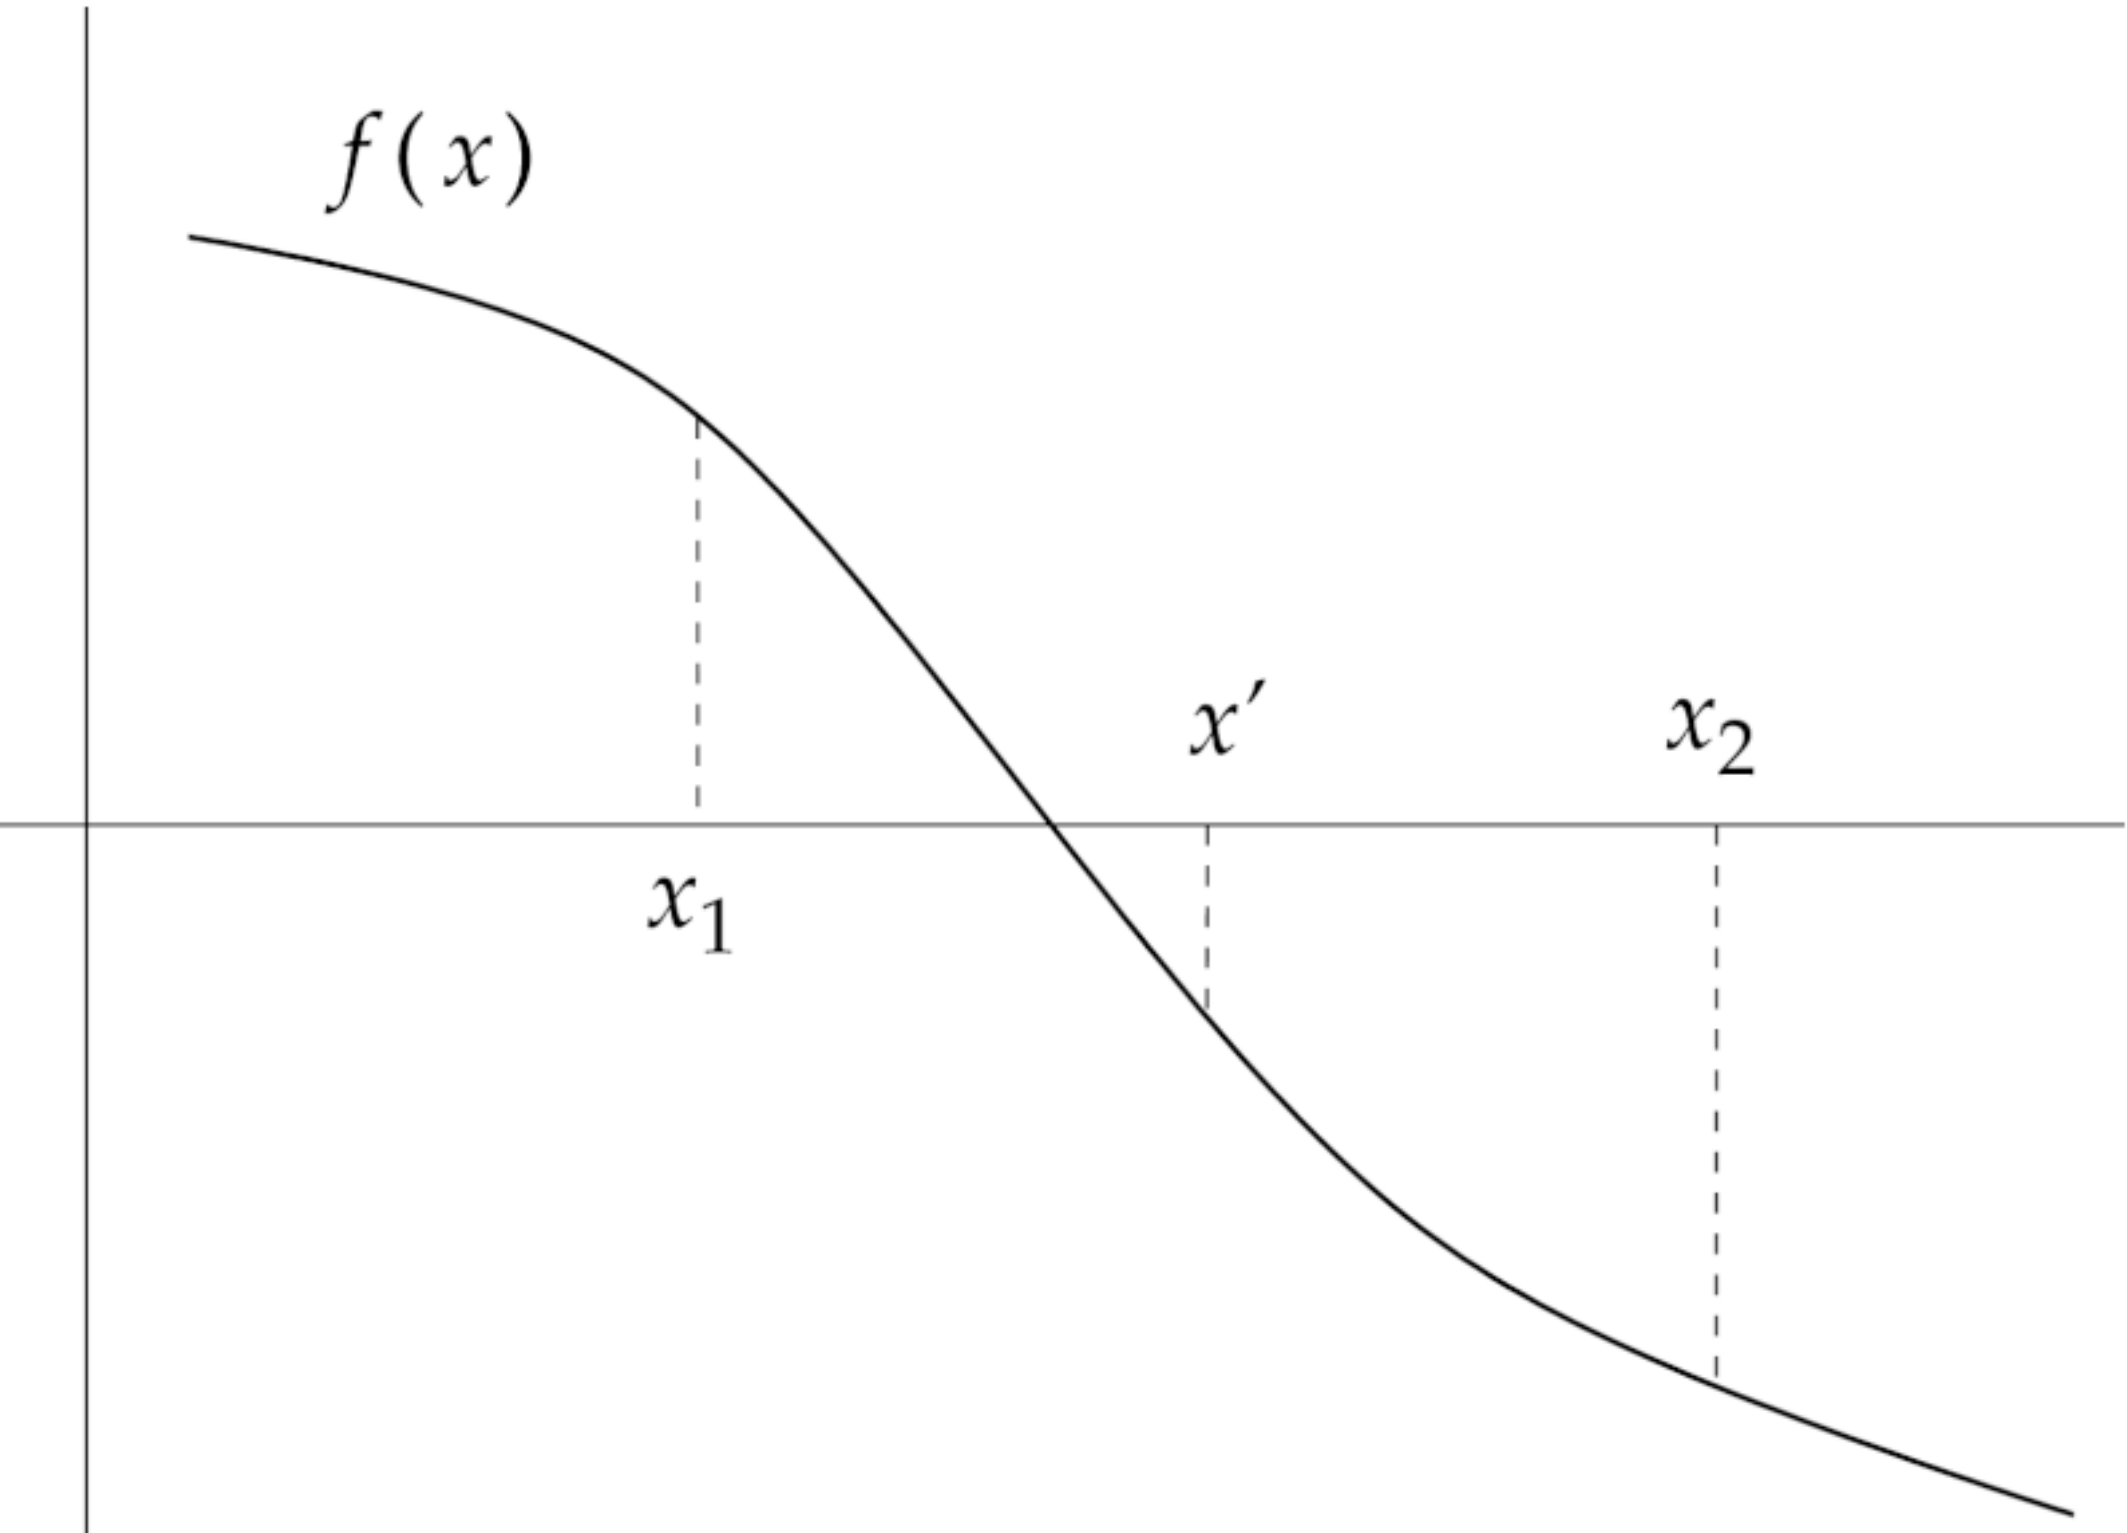

In [7]:
display(Image(filename="bisection.png", width=600, height=600))

### Convergence of the Bisection Method.

- As with the fixed-point method, the precision improves exponentially. 


- The distance between two estimates is halved at each iteration.  
  Therefore, calling $\epsilon_0=| x_1-x_2 |$ the error associated with the initial estimate, after $n$ iterations:
  
  
  $$\epsilon_n=\frac{\epsilon_0}{2^n}=\epsilon_0 \text{e}^{-n\log2}.$$
  
  
- This allows us to calculate the number of iterations $N$ needed to reach a target precision $\epsilon$:

$$N=\log_2\frac{\epsilon_0}{\epsilon}.$$


- Since the logarithm is a slowly growing function, this ensures that with a reasonable number of steps we can find the solution with a given precision. 

---


Bisection method's iterations: 22


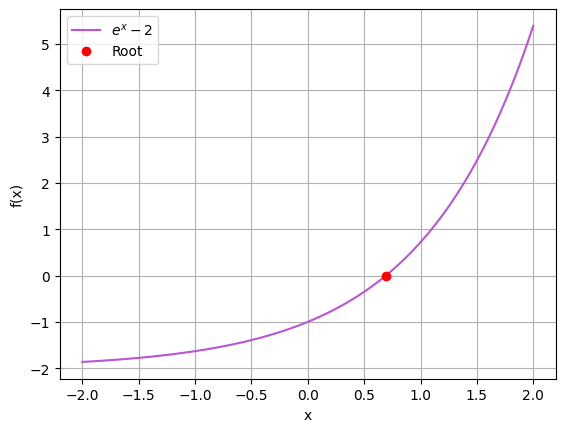

In [8]:
def f(x):
    return np.exp(x) - 2

x = np.linspace(-2, 2, 100)
plt.plot(x, f(x), color = 'mediumorchid', label = "$e^x - 2$")
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')


def bisection(f, a, b, eps):
    fa = f(a)
    fb = f(b)

    it = 0
    while b - a > eps:
        m = a + (b - a) / 2.0
        fm = f(m)
        it += 1

        if np.sign(fa) == np.sign(fm):
            a = m
            fa = fm
        else:
            b = m
            fb = fm
    print("Bisection method's iterations:", it)
    return m

x0 = bisection(f, -2, 2, 1e-6)

plt.plot(x0, 0, 'ro', label = 'Root')
plt.legend()
plt.show()

### Limitations of the Bisection Method:

- If, given our initial interval, $f(x_1)$ and $f(x_2)$ have the same sign, the method does not work.  


- Moreover, this may be because there is no solution, or because there is an even number of solutions.  
  Unfortunately, it is not easy to distinguish between these two possibilities.


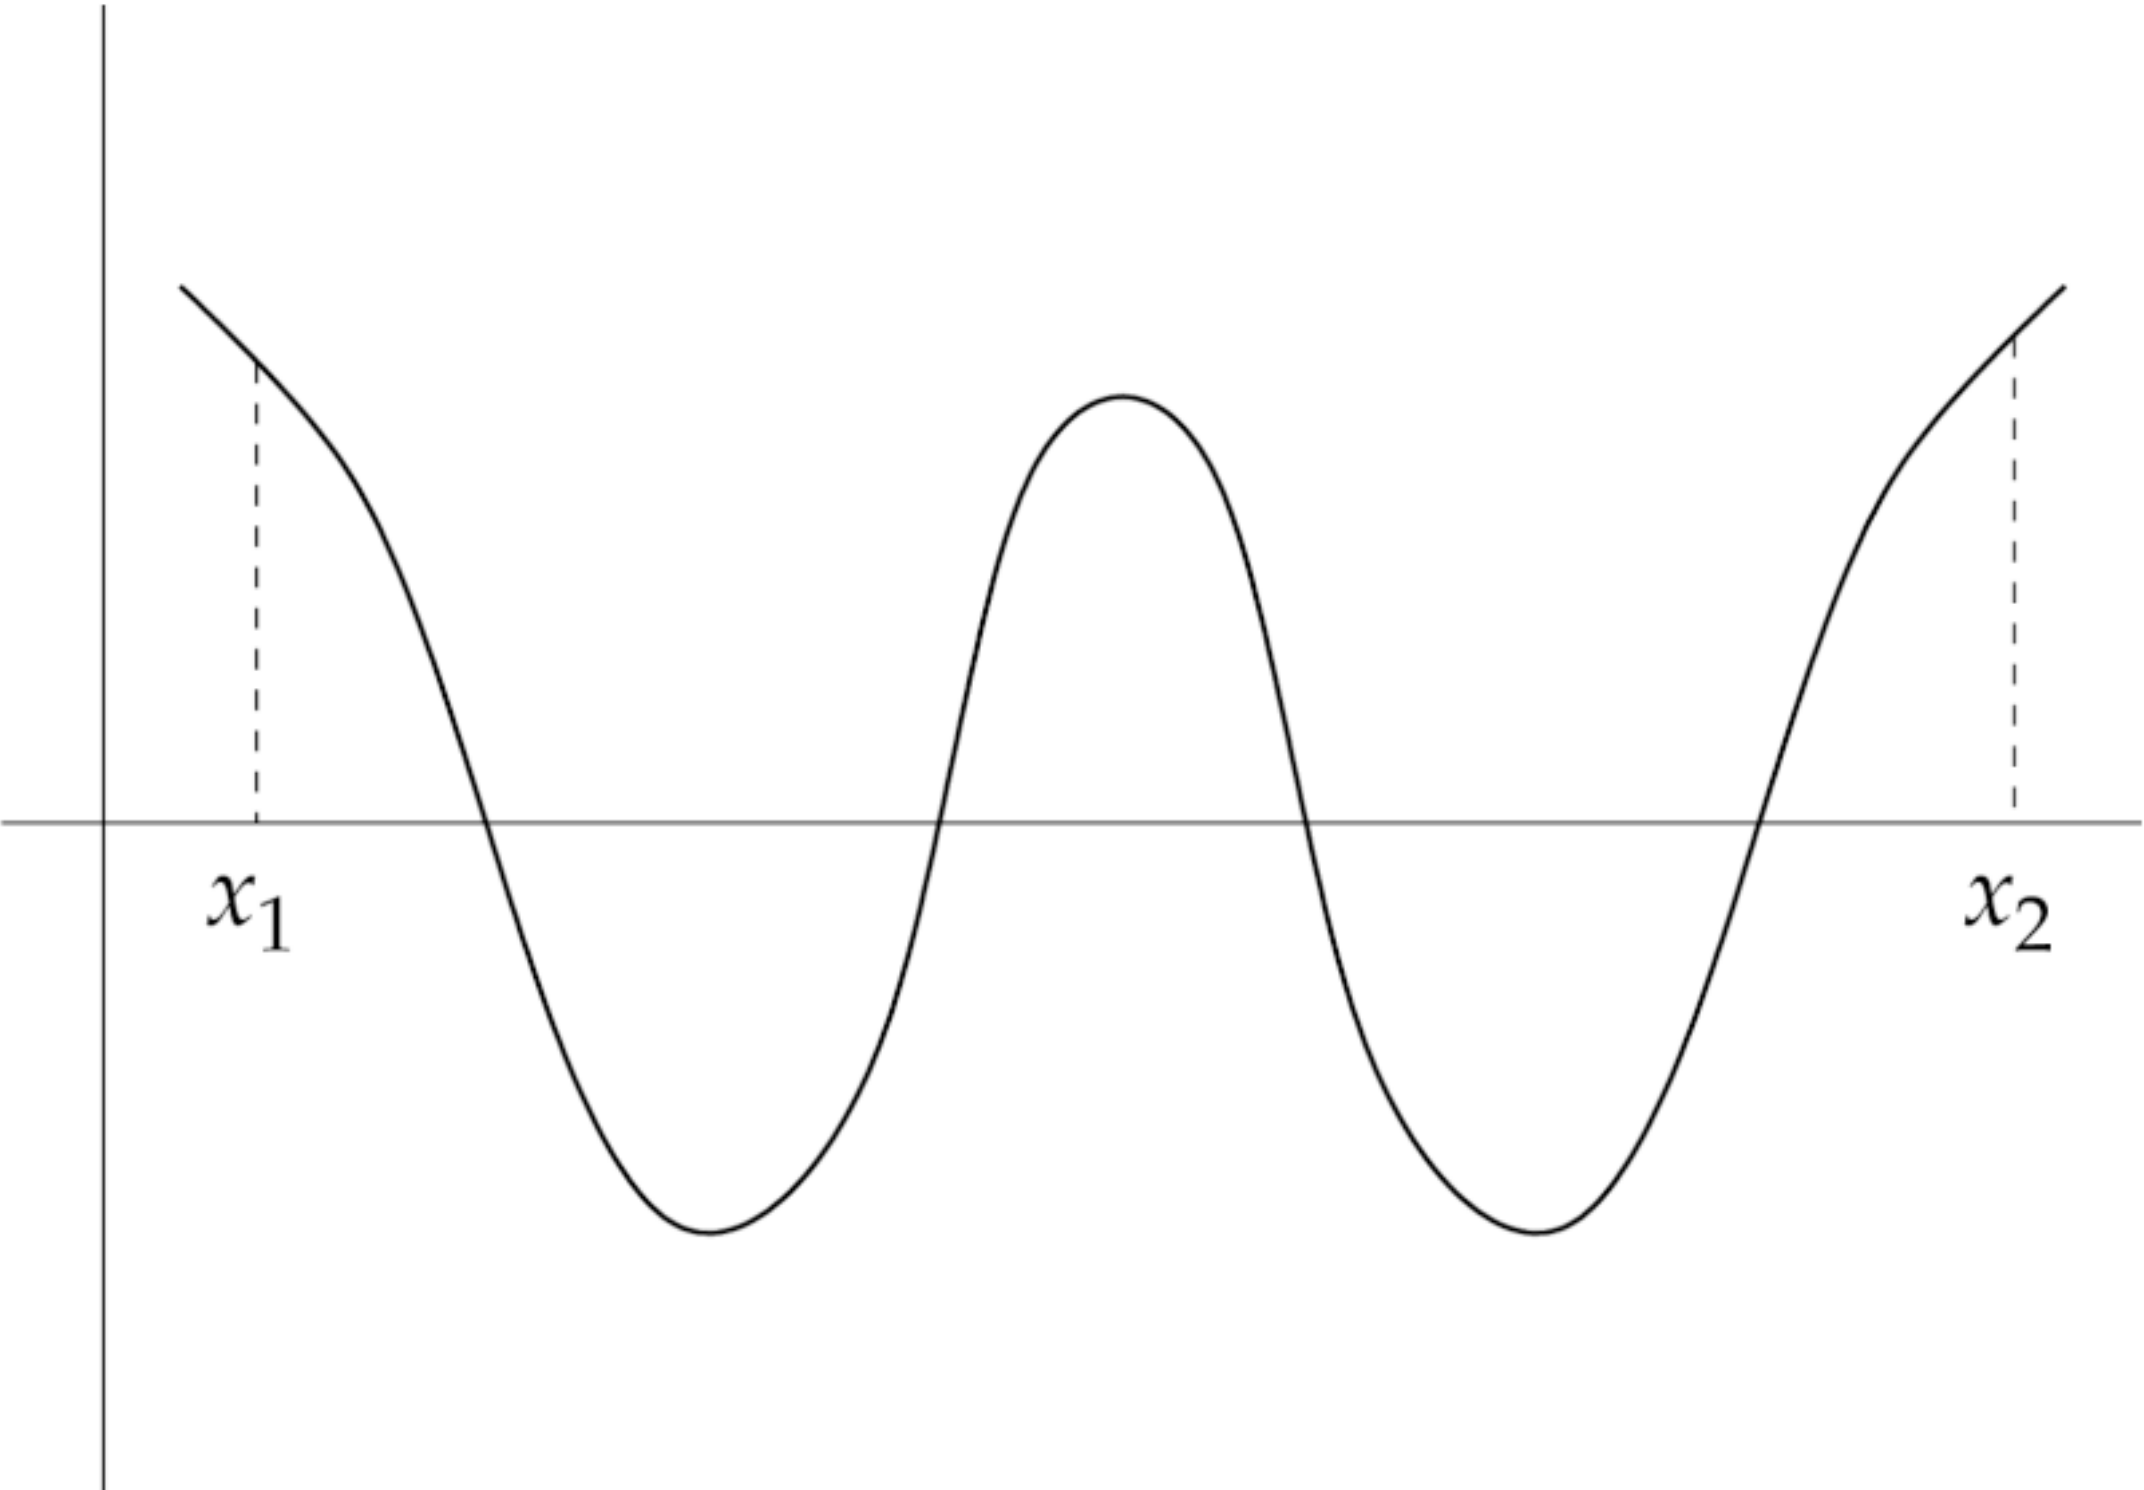

In [9]:
display(Image(filename="bisection2.png", width=600, height=600))

## Newton-Raphson Method.

- Both the fixed-point method and the bisection method are fast and simple, but they have drawbacks.  


- The fixed-point or relaxation method does not always converge to the solution.  


- The bisection method requires defining an initial interval that contains the root of the function.  


- The Newton-Raphson method is even faster than the previous two.  


- Like the bisection method, it consists of finding a solution to the equation

    $$f(x)=0,$$

    that is, finding the roots of the function, which are estimated by extrapolating the slope of the function at a given point.

- Given an initial estimate $x$, the new estimate is given by:

$$x'=x-\Delta x = x-\frac{f(x)}{f'(x)},$$

$\quad$ which therefore requires knowing the derivative of the function.  

- By repeating the procedure iteratively, one obtains (in general) an increasingly better estimate of the root.

### Disadvantages of the Newton-Raphson Method.

- We need to know the derivative of $f(x)$.  


- The method does not always converge:  
  for example, if $f'(x)$ is very small, the iterative method will make the error of each iteration larger than the previous one.  


- It may occur that the slope of the function points in the direction opposite to the root.


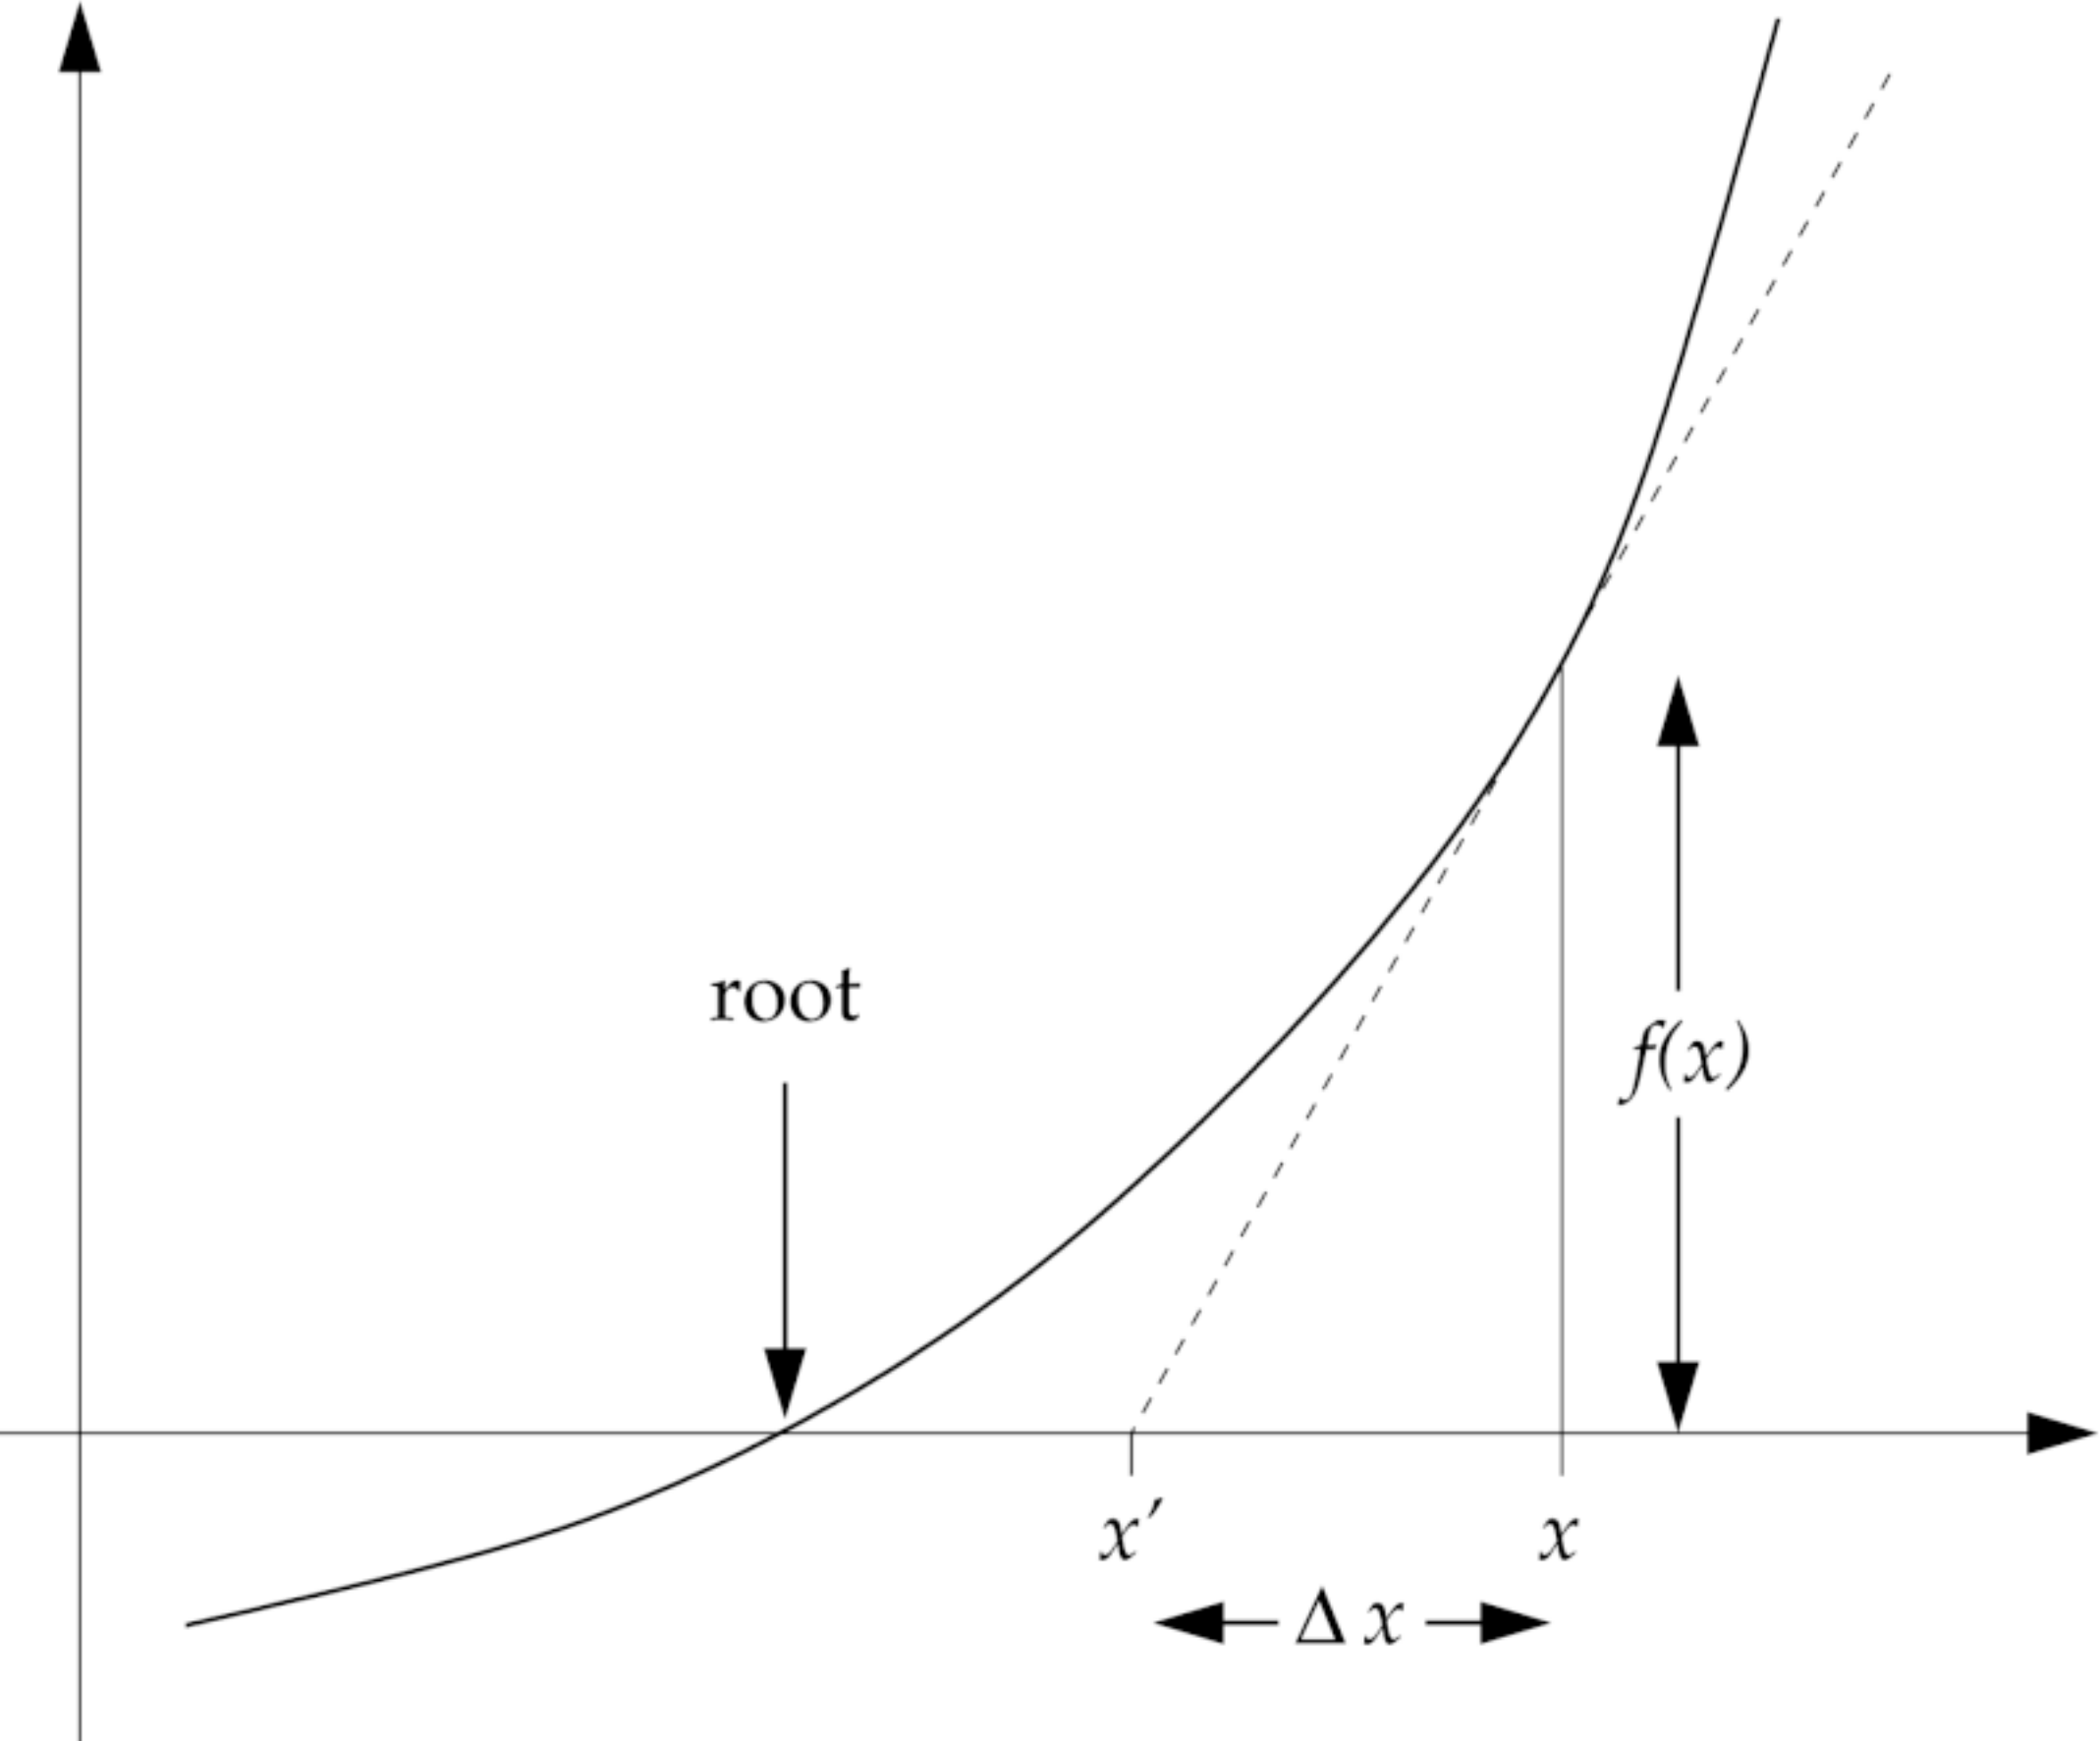

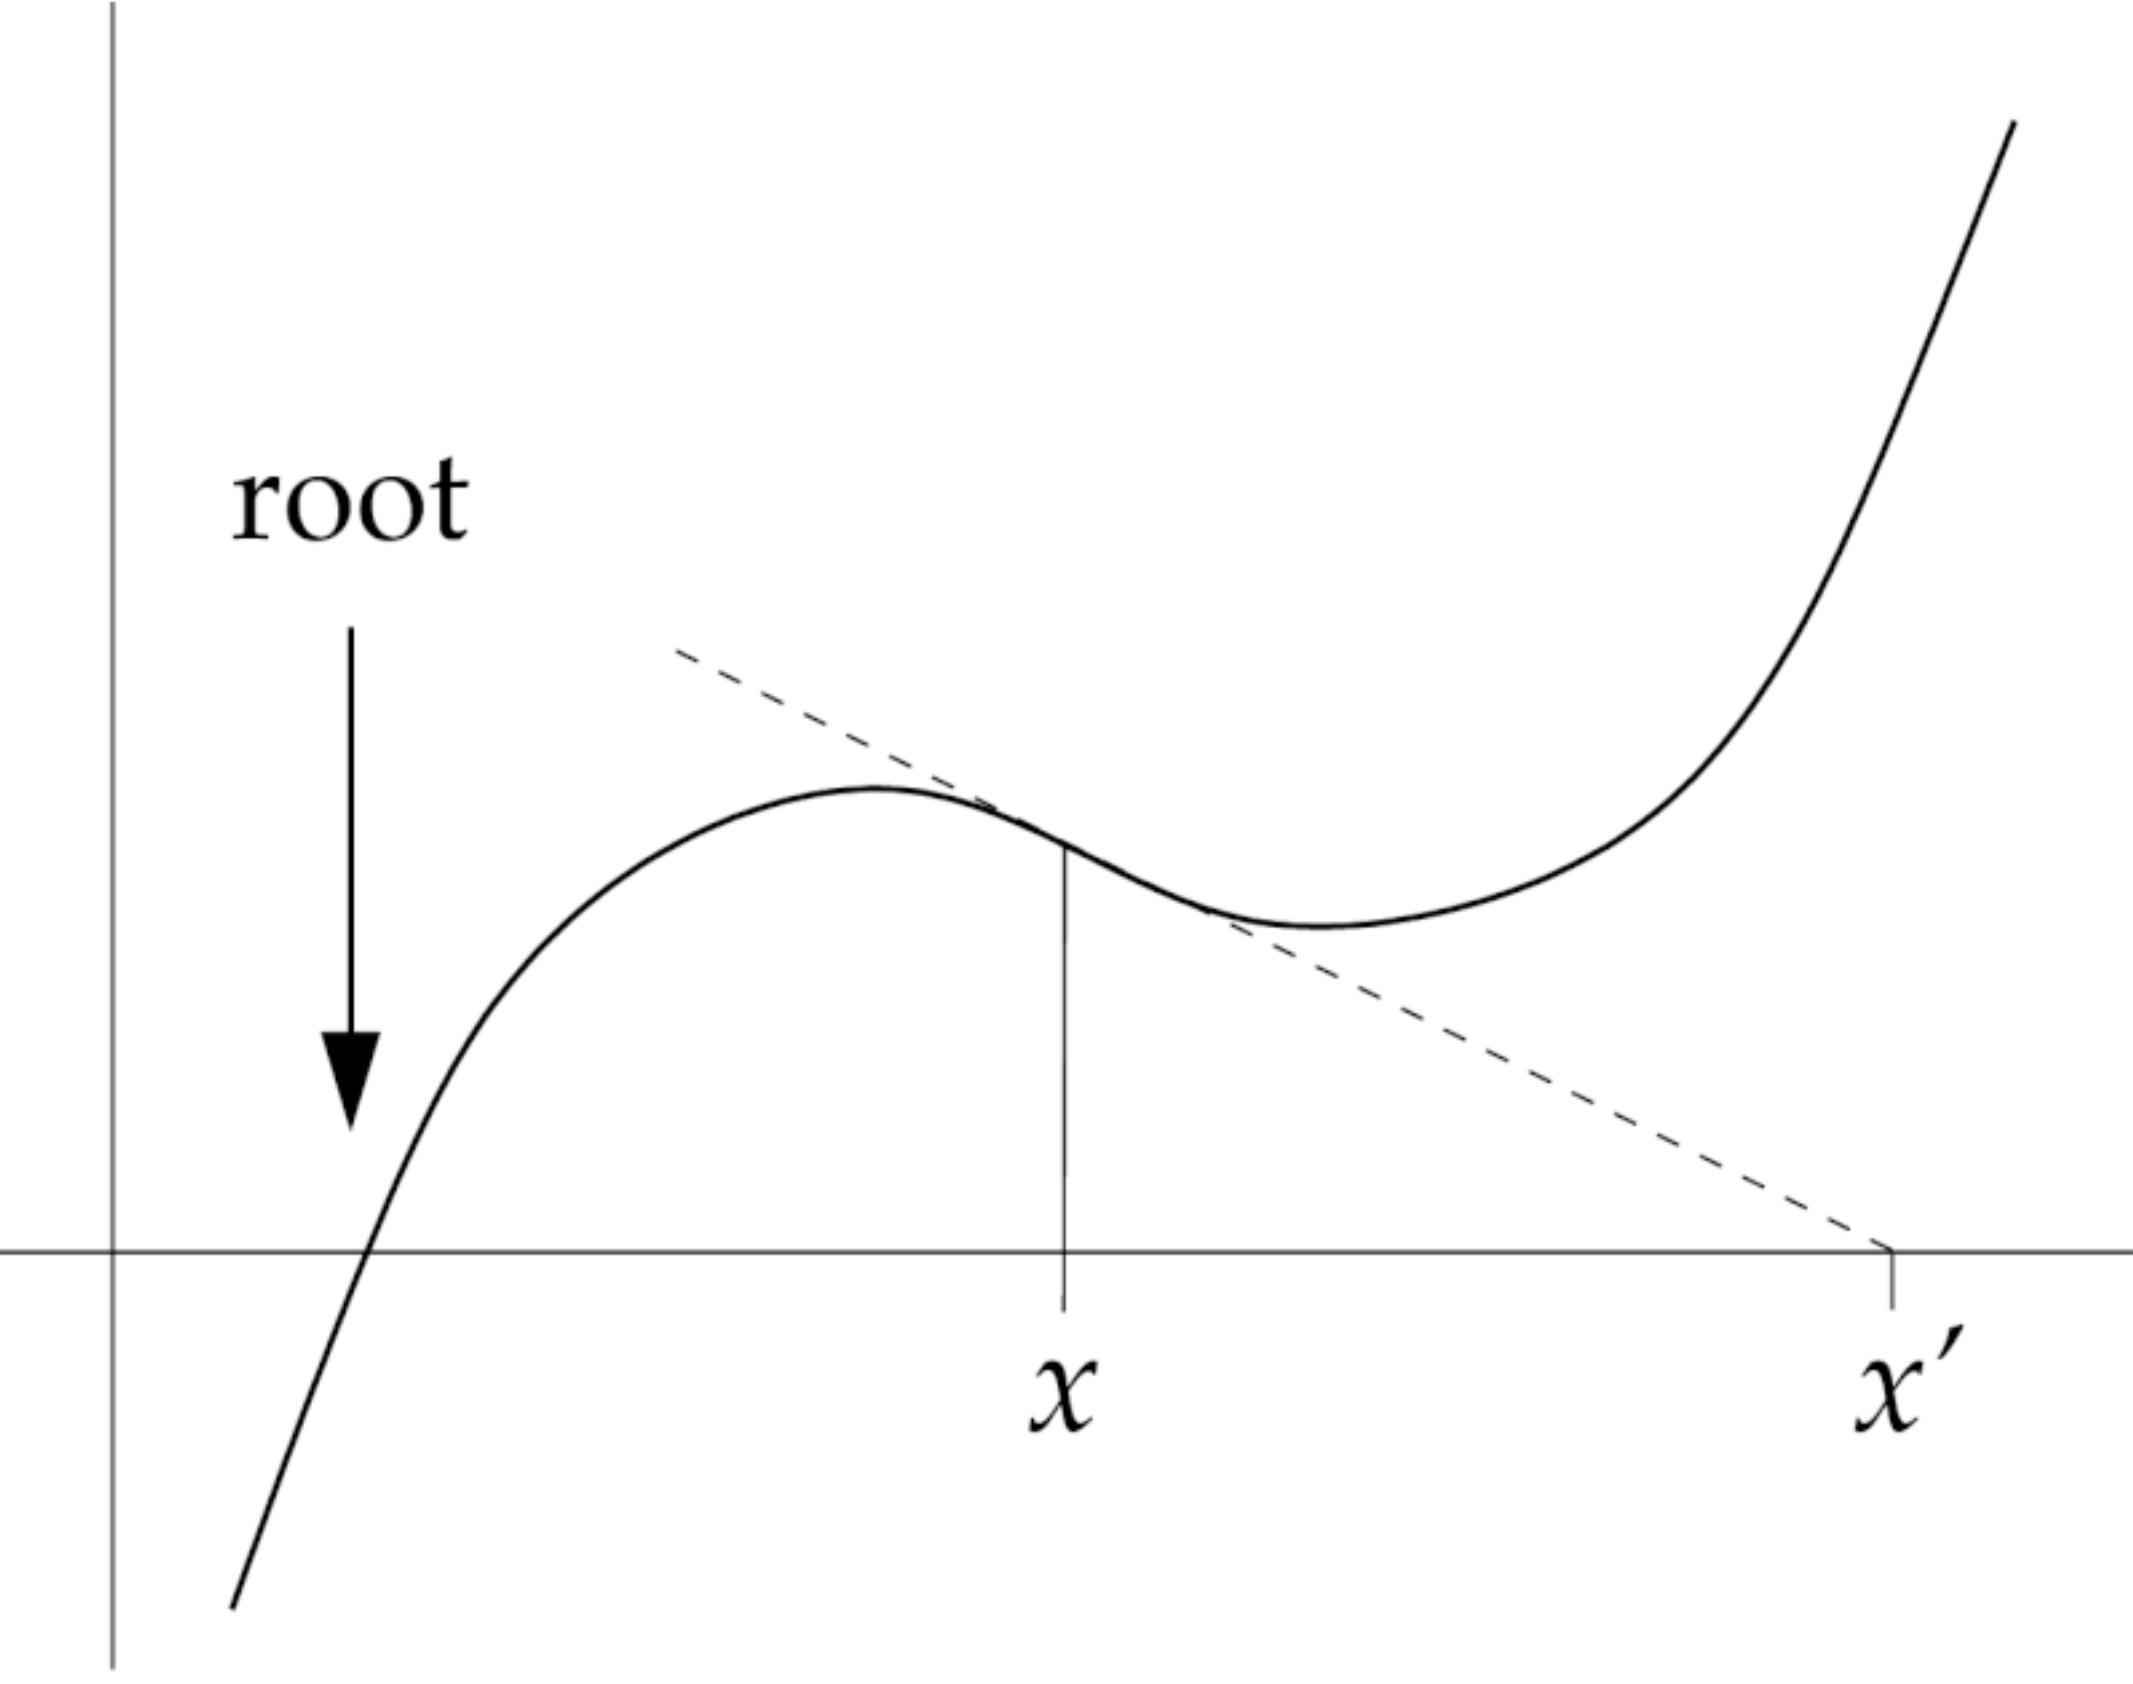

In [10]:
display(Image("newton.png",width=450,height=450))
display(Image("newton2.png",width=450,height=450))

Newton-Raphson method's iterations: 7


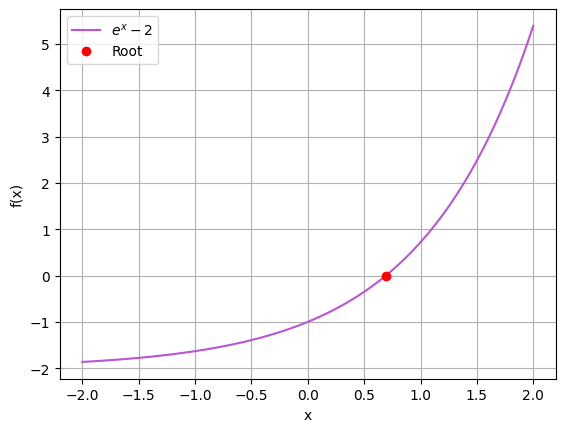

In [11]:
def newton_raphson(f, x0, eps, printing = True):
    def df(x):
        h = 1e-10
        return (f(x + h / 2) - f(x - h / 2)) / h

    it = 0
    while abs(f(x0)) > eps:
        x0 = x0 - f(x0) / df(x0)
        it += 1

    if printing:
        print("Newton-Raphson method's iterations:", it)
    return x0

plt.plot(x, f(x), color = 'mediumorchid', label = "$e^x - 2$")
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')

x0 = newton_raphson(f, 4, 1e-6)

plt.plot(x0, 0, 'ro', label = 'Root')
plt.legend()
plt.show()

Newton-Raphson method's iterations: 5


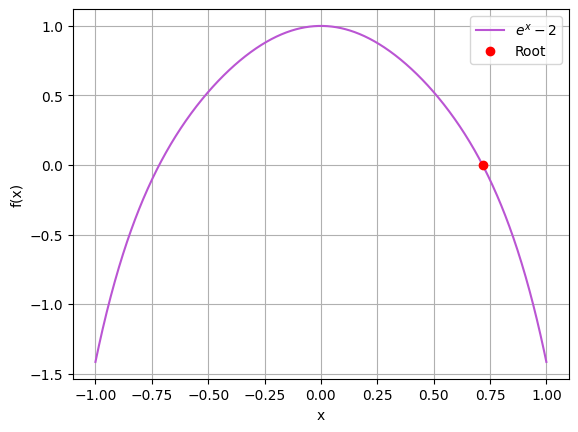

In [12]:
def g(x):
    return np.cos(2*x) - x**6
x = np.linspace(-1, 1, 1000)

plt.plot(x, g(x), color = 'mediumorchid', label = "$e^x - 2$")
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')

x0 = newton_raphson(g, 1, 1e-8)

plt.plot(x0, 0, 'ro', label = 'Root')
plt.legend()
plt.show()

Newton-Raphson method's iterations: 3


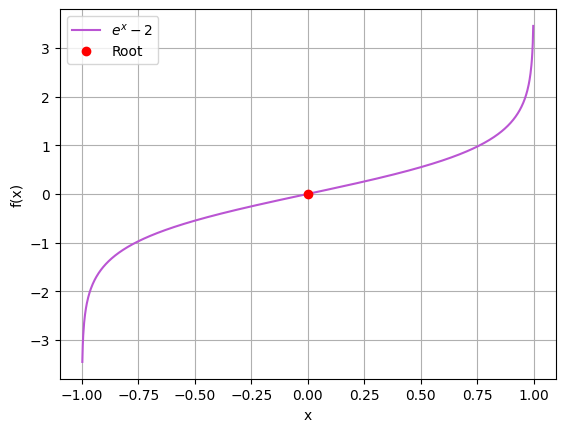

In [13]:
def g(u):
    return np.arctanh(u)

plt.plot(x, g(x), color = 'mediumorchid', label = "$e^x - 2$")
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')

x0 = newton_raphson(g, 0.25, 1e-8)

plt.plot(x0, 0, 'ro', label = 'Root')
plt.legend()
plt.show()

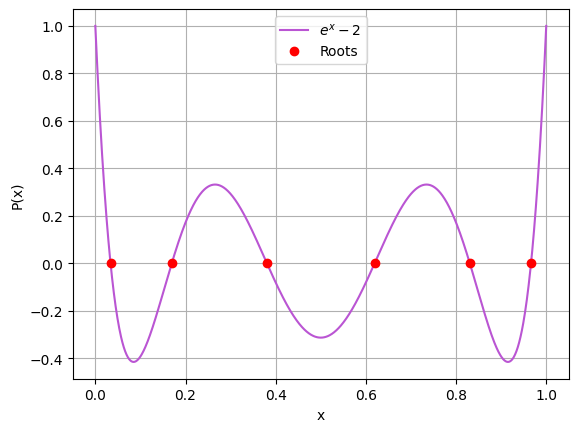

In [14]:
def P(x):
    return 924*x**6-2772*x**5+3150*x**4-1680*x**3+420*x**2-42*x+1


x = np.linspace(0, 1, 1000)
plt.plot(x, P(x), color = 'mediumorchid', label = "$e^x - 2$")
plt.grid()
plt.xlabel('x')
plt.ylabel('P(x)')

x0 = [0.05, 0.15, 0.4, 0.6, 0.8, 1]
roots = [newton_raphson(P, root, 1e-12, printing=False) for root in x0]
plt.plot(roots, np.zeros([len(x0)]), 'ro', label = 'Roots')
plt.legend()
plt.show()

### Newton-Raphson Method for More Than One Variable.

- Consider a set of $N$ non-linear equations for N variables $x_1\cdots,x_N$

    \begin{align}
    f_1(x_1,\cdots,x_N)=&\;0\,,\nonumber\\
    f_2(x_1,\cdots,x_N)=&\;0\,,\nonumber\\
    \vdots\quad\quad\quad &\;\vdots\nonumber\\
    f_N(x_1,\cdots,x_N)=&\;0\,,\nonumber\\
    \end{align}

    whose roots are $\bar x_1,\cdots,\bar x_N$.


- Expanding each equation in a Taylor series:

    $$f_i(\bar x_1,\cdots,\bar x_N)=f_i(x_1,\cdots,x_N)+\sum_j{\left(\bar x_j-x_j\right)}\frac{\partial f_i}{\partial x_j}+\cdots,$$

    which in vector notation can be expressed as

    $$F(\bar x)=F(x) + J\cdot(\bar X- X)+\cdots,$$

    where $J$ is the Jacobian matrix of the system of equations, i.e., the $N\times N$ matrix with elements $J_{ij}=\frac{\partial f_i}{\partial x_j}$.


- Since the vector $\bar X$ is a solution of the system, we have $F(\bar x)=0$, and

    $$J\cdot(X-\bar X)=J\cdot\Delta X=F(x),$$

     which is exactly the generalization of the Newton-Raphson method for more than one variable,   
     and can be solved using the methods we have seen for linear systems of equations.  


- Once we have obtained $\Delta X$, we can get the new estimate from:

    $$X'=X-\Delta X.$$


- In case the Jacobian matrix is not known, it can be estimated using the finite difference method, which therefore generalizes the secant method for more than one variable.


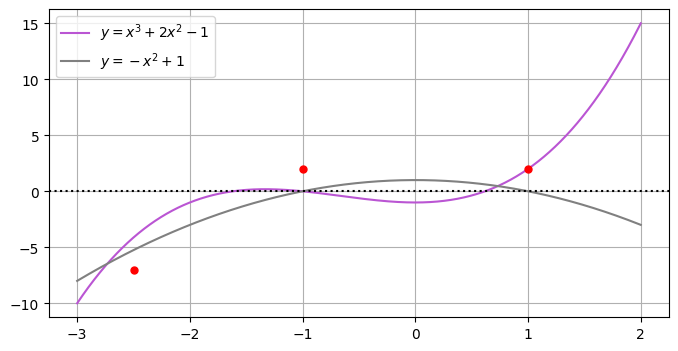

In [15]:
def f(x):
    return np.array([
        x[1] - x[0]**3 - 2*x[0]**2 + 1,
        x[1] + x[0]**2 - 1
    ])

def fJ(x):
    return np.array([
        [-3*x[0]**2 - 4*x[0], 1],
        [2*x[0], 1]
    ])

x = np.linspace(-3, 2, 5000)
y1 = x**3 + 2*x**2 - 1
y2 = -x**2 + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y1, lw=1.5, color = "mediumorchid", label=r"$y = x^3 + 2x^2 - 1$")
ax.plot(x, y2, lw=1.5, color = "gray", label=r"$y = -x^2 + 1$")
ax.legend(loc=0)
ax.axhline(0, color = 'k', ls=":")
plt.grid()

x0 = np.array([[-2.5, -7], [-1, 2], [1, 2]], float)

for i in x0:
    ax.plot(i[0], i[1], "ro", markersize=5)

plt.show()

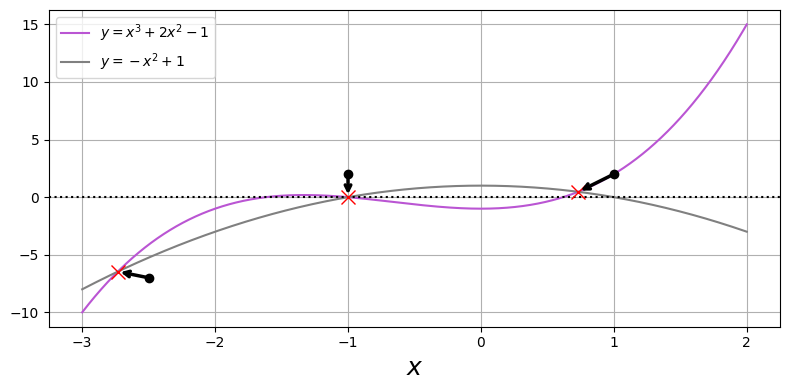

In [16]:
eps = 1e-6
x1 = np.copy(x0)
it = 0

for i in x1:
    err = 1.0
    while err > eps:
        dx = np.linalg.solve(fJ(i), f(i))
        i -= dx
        err = abs(np.max(dx))
    x1[it] = i
    it += 1

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y1, lw=1.5, color = "mediumorchid", label=r"$y = x^3 + 2x^2 - 1$")
ax.plot(x, y2, lw=1.5, color = "gray", label=r"$y = -x^2 + 1$")
plt.axhline(0, ls=':', color='k')

for k in range(3):
    ax.plot(x1[k, 0], x1[k, 1], 'rx', markersize=10)
    ax.plot(x0[k, 0], x0[k, 1], 'ko')
    ax.annotate(
        "",
        xy=(x1[k, 0], x1[k, 1]),
        xytext=(x0[k, 0], x0[k, 1]),
        arrowprops=dict(arrowstyle="->", linewidth=2.5)
    )

ax.legend(loc=0)
ax.set_xlabel(r'$x$', fontsize=18)
fig.tight_layout()
plt.grid()
plt.show()

[-2.73205081 -6.46410162] [-2.73205081 -6.46410162]
[-1.  0.] [-1.  0.]
[0.73205081 0.46410162] [0.73205081 0.46410162]


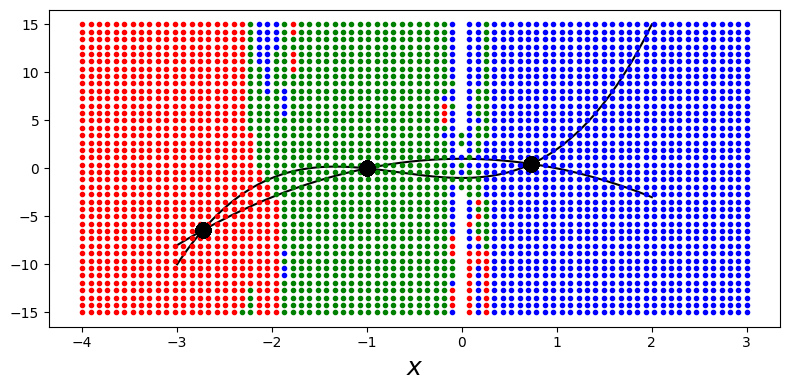

In [17]:
sol1=optimize.fsolve(f,x0[0])
sol2=optimize.fsolve(f,x0[1])
sol3=optimize.fsolve(f,x0[2])
print(sol1,x1[0])
print(sol2,x1[1])
print(sol3,x1[2])
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y1, 'k', lw=1.5, label=r'$y = x^3 + 2x^2 - 1$')
ax.plot(x, y2, 'k', lw=1.5, label=r'$y = -x^2 + 1$')

colors = ['r', 'g', 'b']

for m in np.linspace(-4, 3, 80):
    for n in np.linspace(-15, 15, 40):
        x00 = [m, n]
        sol = optimize.fsolve(f, x00)
        for idx, s in enumerate([sol1, sol2, sol3]):
            if abs(s - sol).max() < 1e-5:
                ax.plot(sol[0], sol[1], 'ko', markersize=10)
                ax.plot(x00[0], x00[1], colors[idx] + '.')

ax.set_xlabel(r'$x$', fontsize=18)
fig.tight_layout()
plt.show()

# Maxima and Minima of Functions. Minimization.

- The search for minima appears continuously in Physics:

    - equilibrium solutions,
    - potential minima,
    - variational problems,
    - ground state of the wavefunction of a physical system in Quantum Mechanics,
    - systems of equations with more data than parameters.
    - calculation of lower or upper bounds.

- Minimization of functions of one variable $f(x)$ or several variables $f(x_1,x_2,\cdots)$.

- Global minima: the minimum of the function over its entire domain.

- Local minima: a point where the function takes a smaller value than any of its surroundings (unstable equilibrium positions).

- While in general there is usually only one global minimum, there can be several local minima.

- Numerical methods do not tell us if it is local or global.

### General Method:

- If it is possible to calculate the derivative:

     - Find the stationary points where the derivative or partial derivatives vanish.  
       If we are looking for the minimum of a function: $f(x_1,x_2,\cdots)$ we solve the system:

       $$\frac{\partial f(x_1,x_2\cdots)}{\partial x_j}=0,\;j=1,2,\cdots$$

     - If the system of equations is linear, we apply LU factorization or the iterative methods we have seen in section 5.1.  
     <br>
     
     - If it is a non-linear system, we can use the fixed-point/relaxation method or the Newton-Raphson method.   
       The application of the Newton-Raphson method to the search for minima is called the Gauss-Newton method.

- If it is not possible to calculate the derivative, it is necessary to find the minimum with numerical methods.

---

## Golden Section Method.

- It is analogous to the bisection method but for finding minima.

- It only works for functions of one variable: we search for the minima of $f(x)$.

- Like the bisection method, it requires starting from two values of the variable $x$ that contain the minimum.

1. Starting from the initial estimates $x_1$ and $x_4$, we assume that the minimum of the function $f(x)$ is contained in the interval $[x_1,x_4]$.

2. Select two interior points $x_2$ and $x_3$ in the interval $[x_1,x_4]$.

3. If the function at at least one of them $f(x_2)$ or $f(x_3)$ is smaller than at $f(x_1)$ and $f(x_4)$, then we can assume that there is at least one minimum of the function (local or global).

    - If $f(x_2)< f(x_3)$ then the minimum will be in the interval $[x_1,x_3]$.
    - If $f(x_2) > f(x_3)$ then the minimum will be in the interval $[x_2,x_4]$.

   This allows us to reduce the interval in which the minimum is located and, by choosing an additional point, we can repeat the process iteratively.

4. The problem lies in optimizing the position of points $x_2$ and $x_3$.

**Optimizing the position of the interior points.** 

1. Since we do not know on which side of the interval $[x_1,x_4]$ the minimum is, $x_2$ and $x_3$ must be symmetrically distributed:

$$x_2-x_1 =x_4-x_3.$$

2. If $x_2$ and $x_3$ are very close to the center of the interval $[x_1,x_4]$, the interval of the next iteration $[x_1,x_3]$ or $[x_2,x_4]$ will be larger.    
   We define the ratio between the intervals in two consecutive iterations:

\begin{align}
   z=&\frac{x_4-x_1}{x_3-x_1}=\frac{x_2-x_1+x_3-x_1}{x_3-x_1}=\frac{x_2-x_1}{x_3-x_1}+1,\quad\text{if}\; f(x_2)<f(x_3),\nonumber\\
   z=&\frac{x_4-x_1}{x_4-x_2}=\frac{x_4-x_2+x_4-x_3}{x_4-x_2}=\frac{x_4-x_3}{x_4-x_2}+1,\quad\text{if}\; f(x_2)>f(x_3),\nonumber\\
\end{align}

3. Redefining the same ratio in the next iteration (assuming the function at the new point to introduce is smaller):

\begin{align}
   z'=&\frac{x_3-x_1}{x_2-x_1},\quad\text{if}\; f(x_2)<f(x_3),\nonumber\\
   z'=&\frac{x_4-x_2}{x_4-x_3},\quad\text{if}\; f(x_2)>f(x_3),\nonumber\\
\end{align}

$\quad$ If we want the algorithm to be equally efficient in two successive iterations, we must impose $z=z'$ which implies

$$z^2-z-1=0,$$

$\quad$ since z>1 we can only take the positive solution which implies:

$$z=\frac{1+\sqrt 5}{2}=1.618...$$

$\quad$ which is the golden ratio. 

4. Once we have the value of $z$, we can uniquely determine the value of the interior points:

$$x_2=x_4-\frac{x_4-x_1}{z},\quad x_3=x_1+\frac{x_4-x_1}{z}$$

---

### Algorithm of the Golden Section Method.

1. Choose a precision for obtaining the minimum.

2. Choose two points at the ends of the interval in which we will search for the minimum $x_1$ and $x_4$.

    - Calculate the interior points $x_2$ and $x_3$ using the golden ratio rule.
    - Evaluate $f(x)$ at the four points and check that at least one of the values of the function at $x_2$ or $x_3$ is smaller than at $x_1$ and $x_4$.

3. If $f(x_2)<f(x_3)$ then the minimum is between $x_1$ and $x_3$; in this case $x_3$ becomes the new $x_4$, $x_2$ becomes the new $x_3$, and there will be a new $x_2$ obtained using the golden ratio rule. Evaluate $f(x)$ at this new point.

4. Otherwise, the minimum is between $x_2$ and $x_4$, then $x_2$ becomes the new $x_1$, $x_3$ becomes the new $x_2$, and there will be a new $x_3$ chosen using the golden ratio rule. Evaluate $f(x)$ at this new point.

5. If $x_4−x_1$ is greater than the required precision, repeat from step 3.   
   Otherwise, calculate $\frac{1}{2}(x_2+x_3)$ and this will be our final estimate of the position of the minimum.

---

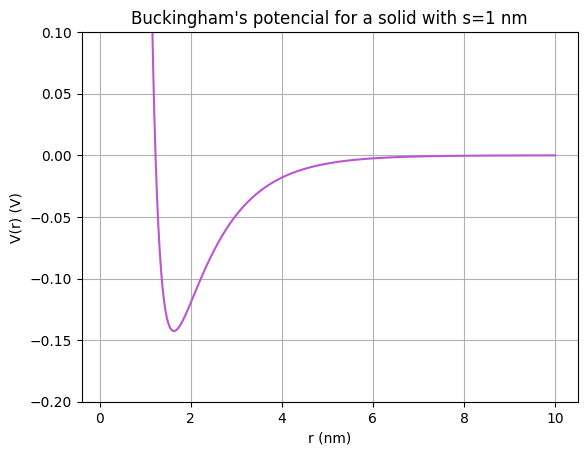

There's at least one local minimum in the interval
Minimum at: 1.630516067174875


In [18]:
def V(r):
    from numpy import exp
    s=1
    return (s/r)**6-exp(-r/s)

r = np.linspace(0.1, 10, 1000)
plt.plot(r, V(r), color = 'mediumorchid')
plt.grid()
plt.ylim(-0.2, 0.1)
plt.xlabel('r (nm)')
plt.ylabel('V(r) (V)')
plt.title("Buckingham's potencial for a solid with s=1 nm")
plt.show()

def golden_ration(f, eps, x1, x4):
    z = (1 + np.sqrt(5)) / 2

    x2 = x4 - (x4 - x1) / z
    x3 = x1 + (x4 - x1) / z

    if f(x2) < f(x1) and f(x2) < f(x4):
        print("There's at least one local minimum in the interval")
    elif f(x3) < f(x1) and f(x3) < f(x4):
        print("There's at least one local minimum in the interval")
    else:
        print("There are no local minimums in the interval")

    while x4 - x1 > eps:
        if f(x2) < f(x3):
            x4 = x3
            x3 = x2
            x2 = x4 - (x4 - x1) / z
        else:
            x1 = x2
            x2 = x3
            x3 = x1 + (x4 - x1) / z

    minimum = (x1 + x4) / 2
    print(f"Minimum at: {minimum}")

    return minimum

x0 = golden_ration(V, 1e-6, 0.1, 10)